# Diabetes Prediction Model using Logistic Regression From Scratch


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in columns:
    df[col] = df[col].replace(0,df[col].median())

In [7]:
X = df.drop(["Outcome"],axis=1)
Y = df["Outcome"]

In [8]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,30.5,33.6,0.627,50
1,1,85,66,29,30.5,26.6,0.351,31
2,8,183,64,23,30.5,23.3,0.672,32
3,1,89,66,23,94.0,28.1,0.167,21
4,0,137,40,35,168.0,43.1,2.288,33


In [9]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [10]:
X.shape

(768, 8)

In [11]:
Y.shape

(768,)

In [12]:
X = X.to_numpy()
Y = Y.to_numpy()

In [13]:
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train = X[:split_index]
X_test = X[split_index : ]

Y_train = Y[:split_index]
Y_test = Y[split_index : ]


In [14]:
X_train.shape

(614, 8)

In [15]:
X_test.shape

(154, 8)

In [16]:
mean = np.mean(X_train,axis=0)
std = np.std(X_train,axis=0)
X_train = (X_train - mean)/std
X_test = (X_test - mean)/std

In [17]:
w = np.random.randn(X_train.shape[1])
b = 0
epochs = 1000
alpha = 0.5
loss_history = []
n = len(X_train)

In [18]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def binary_cross(y,y_pred,n):
    epsilon = 1e-15
    y_pred = np.clip(y_pred,epsilon,1-epsilon)
    loss = (-1/n) * np.sum(y * np.log(y_pred) + (1-y) * np.log(1-y_pred))
    return loss
def predict(X):
    z = np.dot(X,w) + b
    probability = sigmoid(z)
    return (probability >= 0.5).astype(int)


In [19]:
for i in range(epochs):
    z = np.dot(X_train,w) + b
    y_pred = sigmoid(z)
    
    loss = binary_cross(Y_train,y_pred,n)
    loss_history.append(loss)
    
    error = y_pred - Y_train
    dw = (1/n) * np.dot(X_train.T,error)
    db = (1/n) * np.sum(error)
    
    w = w - alpha * dw
    b = b - alpha * db
    
    if i%100 == 0:
        print(f"Epochs {i} , Loss : {loss:.4f}")
    

Epochs 0 , Loss : 1.6882
Epochs 100 , Loss : 0.4614
Epochs 200 , Loss : 0.4613
Epochs 300 , Loss : 0.4613
Epochs 400 , Loss : 0.4613
Epochs 500 , Loss : 0.4613
Epochs 600 , Loss : 0.4613
Epochs 700 , Loss : 0.4613
Epochs 800 , Loss : 0.4613
Epochs 900 , Loss : 0.4613


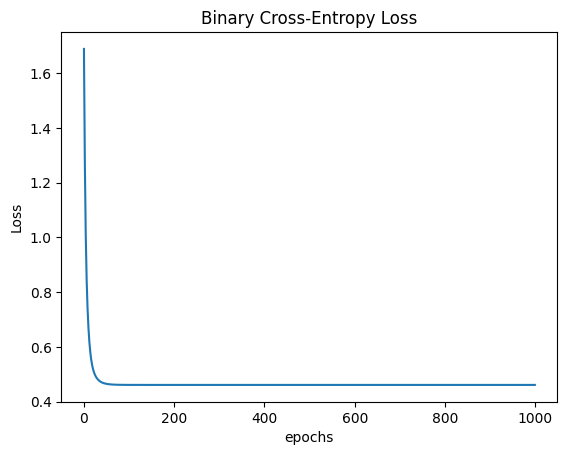

In [20]:
plt.plot(loss_history)
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("Binary Cross-Entropy Loss")
plt.show()

In [21]:
y_pred_test = predict(X_test)
print(y_pred_test)

[0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 1 0
 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 0
 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 1 0
 0 0 0 1 1 0]


In [27]:
TP = np.sum((Y_test == 1) & (y_pred_test == 1))
TN = np.sum((Y_test == 0) & (y_pred_test == 0))
FP = np.sum((Y_test == 0) & (y_pred_test == 1))
FN = np.sum((Y_test == 1) & (y_pred_test == 0))

In [28]:
print("Confusion Matrix")
print(f"TP = {TP}")
print(f"TN = {TN}")
print(f"FP = {FP}")
print(f"FN = {FN}")

Confusion Matrix
TP = 31
TN = 86
FP = 10
FN = 27


In [31]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

In [32]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1_score:.4f}")

Accuracy : 0.7597
Precision: 0.7561
Recall   : 0.5345
F1-Score : 0.6263


In [23]:
def predict_new(data):
    data = np.array(data)
    data = (data - mean) / std
    z = np.dot(data, w) + b
    probability = sigmoid(z)
    prediction = 1 if probability >= 0.5 else 0
    return prediction, probability

In [24]:
new_patient = [7,102,74,40,105,37.2,0.204,45]
prediction,probability = predict_new(new_patient)
print("Prediction : ",prediction)
print("Probability :",probability)

Prediction :  0
Probability : 0.2681112961506936


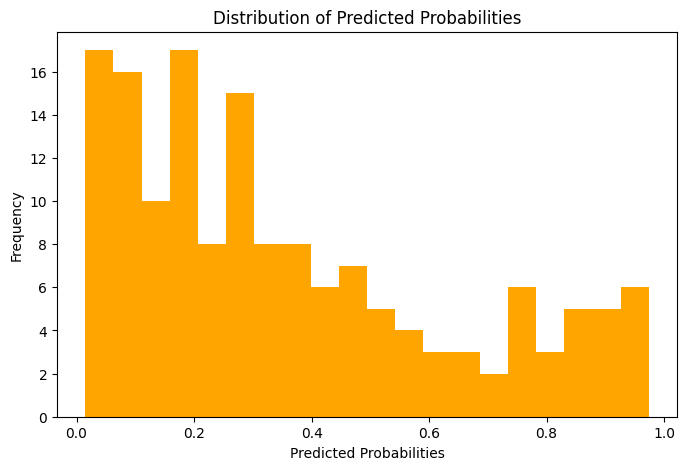

In [25]:
probabilities = sigmoid(np.dot(X_test,w)+b)
plt.figure(figsize=(8,5))
plt.hist(probabilities,bins=20,color="Orange")
plt.xlabel("Predicted Probabilities")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities")
plt.show()


#### X-axis: Predicted probability of having diabetes.
#### Y-axis: Number of patients with probabilities in that range.

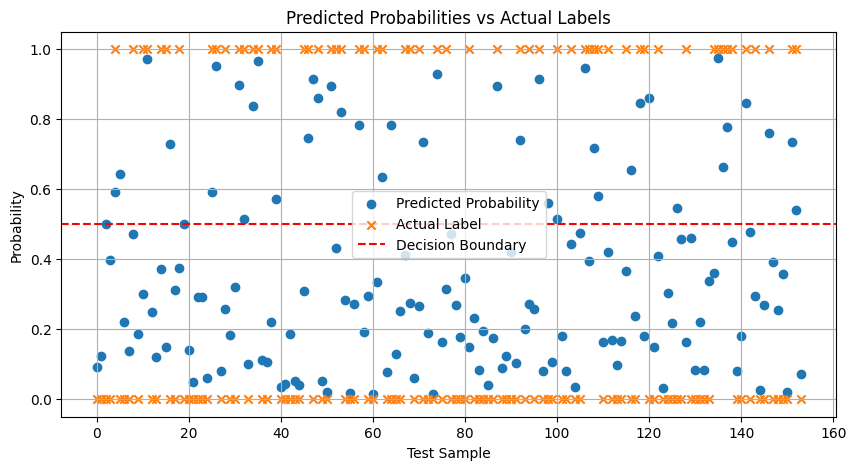

In [35]:
prob = sigmoid(np.dot(X_test, w) + b)

plt.figure(figsize=(10,5))
plt.scatter(range(len(prob)), prob, label="Predicted Probability")
plt.scatter(range(len(Y_test)), Y_test, label="Actual Label", marker="x")

plt.axhline(0.5, color="red", linestyle="--", label="Decision Boundary")

plt.xlabel("Test Sample")
plt.ylabel("Probability")
plt.title("Predicted Probabilities vs Actual Labels")
plt.legend()
plt.grid(True)
plt.show()